# Initialization and basin of attraction

Probe the dependence of the self-training dynamics on the initial signal overlap.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    trajectory_diagnostics,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


The initialization is generated by
$$
w^0=c\,\mu/s_\mu+\sqrt{1-c^2}\,\varepsilon,
\qquad m^0\approx c s_\mu,
$$
where $s_\mu^2=\mathbb E[\widetilde\mu^2]$.  This preserves the initial weight variance while varying its signal overlap.

In [3]:
SEED = 6100
T, D, DELTA = 100, 1_200, 2.0
K_W, K_G = 5_500, 6_500
CORRELATIONS = np.linspace(-0.9, 0.9, 9)
cfg = make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=5.0, kappa=logit(0.8))

runs = {}
for index, correlation in enumerate(CORRELATIONS):
    runs[float(correlation)] = run_experiment(
        name=rf"initial correlation={correlation:.2f}", d=D, delta=DELTA, n_test=3_000,
        label_prior=0.2, rho=0.1, sigma=1.0, signal_std=1.0,
        algo_cfg=cfg, seed=SEED, K_w=K_W, K_g=K_G,
        initialization_correlation=float(correlation),
    )

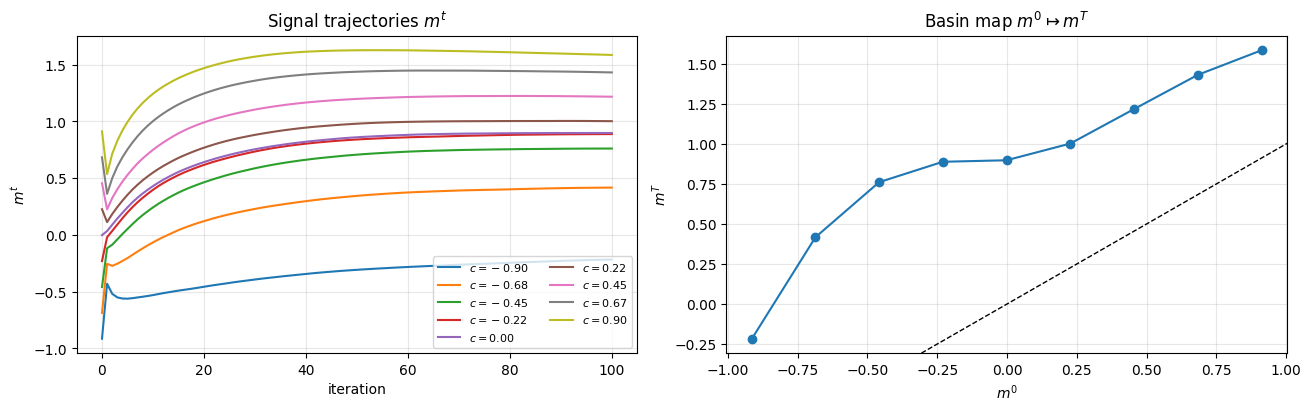

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for correlation, run in runs.items():
    state = state_evolution_state_observables(run)
    axes[0].plot(state["m"], label=rf"$c={correlation:.2f}$")
axes[0].set(title=r"Signal trajectories $m^t$", xlabel="iteration", ylabel=r"$m^t$")
initial_m = np.array([state_evolution_state_observables(run)["m"][0] for run in runs.values()])
final_m = np.array([state_evolution_state_observables(run)["m"][-1] for run in runs.values()])
axes[1].plot(initial_m, final_m, marker="o")
axes[1].axline((0, 0), slope=1, color="black", linestyle="--", linewidth=1)
axes[1].set(title=r"Basin map $m^0\mapsto m^T$", xlabel=r"$m^0$", ylabel=r"$m^T$")
for ax in axes: ax.grid(alpha=0.3)
axes[0].legend(ncol=2, fontsize=8)
plt.show()

A sharp change in the basin map should be checked by increasing both $T$ and the particle populations, and by repeating with multiple finite environments.  The correlation grid describes a controlled initialization family, not all possible initial laws.

## Basin stress test

The displayed map concerns one regime.  The opt-in stress test varies supervision, noise, and pseudo-label weight before interpreting a bend as a basin boundary; candidate boundaries should subsequently be checked with finite-dimensional runs.

In [5]:
RUN_BASIN_STRESS_TEST = True
if RUN_BASIN_STRESS_TEST:
    stress_regimes = ((0.01, 1.0, 5.0, True), (0.01, 2.0, 10.0, True), (0.01, 2.0, 10.0, False))
    stress_results = {}
    for rho, sigma, pi, include_bias in stress_regimes:
        regime_runs = {}
        for index, correlation in enumerate(CORRELATIONS):
            regime_runs[correlation] = run_experiment(name=rf"rho={rho}, sigma={sigma}, pi={pi}, bias={include_bias}, c={correlation}", d=D, delta=DELTA, n_test=2_000, label_prior=0.2, rho=rho, sigma=sigma, signal_std=1.0, algo_cfg=make_algorithm_config(T=T, eta=0.1, penalty=0.1, pi=pi, kappa=logit(0.8), include_bias=include_bias), seed=SEED + 100_000 * len(stress_results) + index, K_w=K_W, K_g=K_G, initialization_correlation=correlation, metadata={"theorem_external": not include_bias})
        stress_results[(rho, sigma, pi, include_bias)] = regime_runs
    for regime, regime_runs in stress_results.items():
        print(regime, {c: trajectory_diagnostics(r)["terminal_normalized_alignment"] for c, r in regime_runs.items()})

(0.01, 1.0, 5.0, True) {np.float64(-0.9): -0.579892992576061, np.float64(-0.675): -0.12330068675854369, np.float64(-0.45): 0.06527340722127654, np.float64(-0.22499999999999998): 0.19158167287594546, np.float64(0.0): 0.16375840069545702, np.float64(0.22499999999999998): 0.11691554236269783, np.float64(0.45000000000000007): 0.2812599044485483, np.float64(0.6749999999999999): 0.5915211734104516, np.float64(0.9): 0.6946712061271466}
(0.01, 2.0, 10.0, True) {np.float64(-0.9): 0.24550862919063016, np.float64(-0.675): 0.1969055221998205, np.float64(-0.45): 0.15752827268155678, np.float64(-0.22499999999999998): 0.08073423269288267, np.float64(0.0): 0.07236279416072569, np.float64(0.22499999999999998): -0.021427843028569565, np.float64(0.45000000000000007): -0.08889853496608918, np.float64(0.6749999999999999): -0.15892124147893757, np.float64(0.9): -0.1855741257246165}
(0.01, 2.0, 10.0, False) {np.float64(-0.9): 0.21342703213802353, np.float64(-0.675): 0.21306888998557375, np.float64(-0.45): 0.